## Dead Tree Segmentation With Traditional Machine Learning
A traditional feature extraction and classifier approach for recognising and segmenting dead trees from tree canopy aerial imagery. The pipeline DetecTree is used, which computes handcrafted pixel-level features, specifically in color, texture and entropy descriptors. A LightGBM classifier is then utilized to classify each pixel.

**Setup / Usage**<br>
<small>\# !pip install pandas joblib pillow scikit-learn torchvision numpy rasterio lightgbm matplotlib opencv-python PyMaxflow detectree<br>
Recommended: Run this notebook in an empty directory as directories with dataset files will be made</small><br><br>
Run all cells to begin training.<br>
&nbsp;&nbsp;&nbsp;&nbsp;- If pre-augmented dataset is not provided, change data augmentation method at bottom of first cell.<br>
&nbsp;&nbsp;&nbsp;&nbsp;- If 'save_model' is set to True, trained model will be saved to 'detectree_classifier.joblib'.<br>
&nbsp;&nbsp;&nbsp;&nbsp;- Training subset can be adjusted for performance in the 'Classifier Training' cell.<br>
&nbsp;&nbsp;&nbsp;&nbsp;- Ensure specified directories for file output do not exist or are empty, otherwise risks code breakage.<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- <small>Deleting output file directories and re-running may fix potential file-related errors</small>

### Data Augmentation
Input images and ground truth binary masks are:<br>
&nbsp;&nbsp;&nbsp;&nbsp;- Scaled to matching resolutions of (256 x 256)<br>
&nbsp;&nbsp;&nbsp;&nbsp;- Flipped (up, down, left, right)<br>
&nbsp;&nbsp;&nbsp;&nbsp;- Rotated (90, 180, 270)<br>
&nbsp;&nbsp;&nbsp;&nbsp;- Transposed (x and y axis swapped)<br>


In [ ]:
# Imports
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torchvision import transforms
from os import path
import numpy as np
import rasterio as rio
import torch
import torchvision.transforms.functional as TF
import cv2
import joblib

# Setup
img_size = (256, 256)
seed = 17
save_model = True

# Original image directories
RGB_dir = 'USA_segmentation/RGB_images'
mask_dir = 'USA_segmentation/masks'

# Directories for file output
response_dir = 'training/response_tiles'
pred_dir = 'training/predictions'

test_img_dir = 'training/test_imgs'
test_mask_dir = 'training/test_masks'

aug_img_dir = 'dataset/RGB_images_aug'
aug_mask_dir = 'dataset/masks_aug'

# Split dataset into train, val and test sets
def split_dataset(image_dir, mask_dir, test_ratio=0.2, val_size = 0.125, seed=seed):
    image_files = []
    for file in os.listdir(image_dir):
        parts = file.split("_", 1)
        _, filename = parts
        mask_name = f"mask_{filename}"
        if os.path.exists(os.path.join(mask_dir, mask_name)):
            image_files.append(file)

    image_files = sorted(image_files)

    train_val, test_files = train_test_split(image_files, test_size=test_ratio, random_state=seed)
    train_files, val_files = train_test_split(train_val, test_size=val_size, random_state=seed)

    train_paths = sorted(os.path.join(image_dir, f) for f in train_files)
    val_paths = sorted(os.path.join(image_dir, f) for f in val_files)
    test_paths = sorted(os.path.join(image_dir, f) for f in test_files)

    train_mask_paths = sorted(
        os.path.join(mask_dir, f"mask_{fname.split('_',1)[1]}")
        for fname in train_files
    )
    val_mask_paths = sorted(
        os.path.join(mask_dir, f"mask_{fname.split('_',1)[1]}")
        for fname in val_files
    )
    test_mask_paths = sorted(
        os.path.join(mask_dir, f"mask_{fname.split('_',1)[1]}")
        for fname in test_files
    )

    return train_paths, val_paths, test_paths, train_mask_paths, val_mask_paths, test_mask_paths

# Standardised dataset augmentation
def hflip(image):
    return image.transpose(Image.FLIP_LEFT_RIGHT)

def vflip(image):
    return image.transpose(Image.FLIP_TOP_BOTTOM)

def rotate(image, angle):
    return image.rotate(angle, expand=True)

def augment_inputs(image, mask):
    augmented = []

    augmented.append((image, mask))
    augmented.append((hflip(image), hflip(mask)))
    augmented.append((vflip(image), vflip(mask)))
    augmented.append((vflip(hflip(image)), vflip(hflip(mask))))
    augmented.append((image.transpose(Image.TRANSPOSE), mask.transpose(Image.TRANSPOSE)))

    for angle in [90, 180, 270]:
        augmented.append((rotate(image, angle), rotate(mask, angle)))

    return augmented

# Combined augmentation and resizing for datasets
def process_dataset(image_paths, mask_paths, output_img_dir, output_mask_dir, augment=False):
    os.makedirs(output_img_dir, exist_ok=True)
    os.makedirs(output_mask_dir, exist_ok=True)
    new_image_paths = []
    new_mask_paths = []
    resize = transforms.Resize(img_size, interpolation=transforms.InterpolationMode.NEAREST)

    for img_path, mask_path in zip(image_paths, mask_paths):
        img_basename = os.path.splitext(os.path.basename(img_path))[0]
        mask_basename = os.path.splitext(os.path.basename(mask_path))[0]
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        # Only augment train and validation set
        pairs = augment_inputs(image, mask) if augment else [(image, mask)]
        for i, (img, mask) in enumerate(pairs):
            img_resized = resize(img)
            mask_resized = resize(mask)

            img_filename = f"{img_basename}_aug{i}.png" if augment else f"{img_basename}.png"
            mask_filename = f"{mask_basename}_aug{i}.png" if augment else f"{mask_basename}.png"

            img_out_path = os.path.join(output_img_dir, img_filename)
            mask_out_path = os.path.join(output_mask_dir, mask_filename)

            # Save images to disk
            img_resized.save(img_out_path)
            mask_resized.save(mask_out_path)
            new_image_paths.append(img_out_path)
            new_mask_paths.append(mask_out_path)

    return new_image_paths, new_mask_paths

# Process dataset
train, val, test, train_mask, val_mask, test_mask = split_dataset(RGB_dir, mask_dir)
# Full dataset resizing and augmentation on training and validation set
train_img_paths, train_mask_paths = process_dataset(train, train_mask, aug_img_dir, aug_mask_dir, augment=True)
val_img_paths, val_mask_paths = process_dataset(val, val_mask, aug_img_dir, aug_mask_dir, augment=True)
test_img_paths, test_mask_paths = process_dataset(test, test_mask, test_img_dir, test_mask_dir, augment=False)

train_df = pd.DataFrame({
    'img_filename': [os.path.basename(p) for p in train_img_paths],
    'label': [os.path.basename(p) for p in train_mask_paths]
})
val_df = pd.DataFrame({
    'img_filename': [os.path.basename(p) for p in val_img_paths],
    'label': [os.path.basename(p) for p in val_mask_paths]
})
test_df = pd.DataFrame({
    'img_filename': [os.path.basename(p) for p in test_img_paths],
    'label': [os.path.basename(p) for p in test_mask_paths]
})

img_dir = aug_img_dir
mask_dir = aug_mask_dir


### Computing training responses from ground truth masks
Detectree's supervised learning method requires the ground truth responses in the form of GeoTIFF files. Hence, we convert the input .png ground truth masks into .tif training tiles for the classifier, preserving metadata for standardization.

In [ ]:
def make_response_tile(img_path, mask_filename, mask_dir, response_dir, output_dtype=rio.uint8, dead_val=1, tree_val=0):
    mask_path = path.join(mask_dir, mask_filename)
    response_path = path.join(response_dir, path.basename(img_path).replace(".png", ".tif"))

    # Preserve metadata (if any)
    with rio.open(img_path) as src:
        meta = src.meta.copy()

    mask = np.array(Image.open(mask_path))
    output = (mask > 0).astype(output_dtype) * dead_val
    meta.update(dtype=output_dtype, count=1, nodata=tree_val)

    with rio.open(response_path, "w", **meta) as resp:
        resp.write(output, 1)

    return response_path

def make_response_tiles(img_paths, mask_filenames, mask_dir, response_dir):
    return [make_response_tile(img_path, mask_filename, mask_dir, response_dir)
            for img_path, mask_filename in zip(img_paths, mask_filenames)]



### Classifier Modifications
We modify the classifier to involve a validation set for early stopping, preventing overfitting.<br>
We also record training / validation loss, training time and the IoU on the validation set as the model trains.

In [268]:
from detectree import ClassifierTrainer, pixel_features, pixel_response, settings
import lightgbm
from lightgbm import early_stopping
import glob
import time

def validation_iou_callback(X_val, y_val, iou_scores_list):
    def callback(env):
        model = env.model
        y_pred = model.predict(X_val)
        y_pred_bin = (y_pred > 0.5).astype(np.uint8)

        # Compute IoU
        intersection = np.logical_and(y_pred_bin, y_val).sum()
        union = np.logical_or(y_pred_bin, y_val).sum()
        iou = intersection / union if union > 0 else 0.0

        iou_scores_list.append(iou)
    return callback

def time_callback(times_list):
    def callback(env):
        times_list.append(time.time())
    return callback

# Containers for data during training
eval_results = {}
val_iou_scores = []
training_times = []

# Modify Detectree LightGBM trainer to involve validation data and early stopping
class MyClassifierTrainer(ClassifierTrainer):
    def train_classifier(
        self,
        *,
        split_df=None,
        img_dir=None,
        response_img_dir=None,
        img_filepaths=None,
        response_img_filepaths=None,
        val_img_filepaths=None,
        val_response_img_filepaths=None,
        img_filename_pattern=None,
        method=None,
        img_cluster=None,
    ):
        if split_df is None and response_img_filepaths is None:
            if img_filepaths is None:
                if img_filename_pattern is None:
                    img_filename_pattern = settings.IMG_FILENAME_PATTERN
                if img_dir is None:
                    raise ValueError(
                        "Either `split_df`, `img_filepaths` or `img_dir` must "
                        "be provided"
                    )
                img_filepaths = glob.glob(path.join(img_dir, img_filename_pattern))

            response_img_filepaths = [
                path.join(response_img_dir, path.basename(img_filepath))
                for img_filepath in img_filepaths
            ]

        X_train = pixel_features.PixelFeaturesBuilder(
            **self.pixel_features_builder_kwargs
        ).build_features(
            split_df=split_df,
            img_filepaths=img_filepaths,
            img_dir=img_dir,
            img_filename_pattern=img_filename_pattern,
            method=method,
            img_cluster=img_cluster,
        )

        y_train = pixel_response.PixelResponseBuilder(
            **self.pixel_response_builder_kwargs
        ).build_response(
            split_df=split_df,
            response_img_dir=response_img_dir,
            response_img_filepaths=response_img_filepaths,
            img_filename_pattern=img_filename_pattern,
            method=method,
            img_cluster=img_cluster,
        )

        # Build validation features/labels (if exists)
        if val_img_filepaths and val_response_img_filepaths:
            X_val = pixel_features.PixelFeaturesBuilder(
                **self.pixel_features_builder_kwargs
            ).build_features(
                img_filepaths=val_img_filepaths
            )

            y_val = pixel_response.PixelResponseBuilder(
                **self.pixel_response_builder_kwargs
            ).build_response(
                response_img_filepaths=val_response_img_filepaths
            )
        else:
            X_val, y_val = None, None

        # Train classifier
        clf = self.classifier_class(**self.classifier_kwargs)

        if X_val is not None and y_val is not None:
            clf.fit(
                X_train,
                y_train,
                eval_set=[(X_train, y_train), (X_val, y_val)],
                eval_names=['training', 'validation'],
                eval_metric='binary_logloss',
                callbacks=[
                    early_stopping(stopping_rounds=10),
                    lightgbm.record_evaluation(eval_results),
                    validation_iou_callback(X_val, y_val, val_iou_scores),
                    time_callback(training_times)
                ]
            )
        else:
            clf.fit(X_train, y_train)

        return clf, len(X_train), len(y_train)

### Classifier Training
Ground truths are converted to GeoTIFF format before classifier is trained on training and validation set. Trained model can then be saved to disk.

Input paths: dataset/RGB_images_aug
Response paths: training/response_tiles
Training on 2480 images
[########################################] | 100% Completed | 84.79 s
[########################################] | 100% Completed | 11.71 s
[LightGBM] [Info] Number of positive: 3036992, number of negative: 159492288
[LightGBM] [Info] Total Bins 6785
[LightGBM] [Info] Number of data points in the train set: 162529280, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018686 -> initscore=-3.961128
[LightGBM] [Info] Start training from score -3.961128
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] Detected that num_threads changed during training (from 6 to 12), it may cause unexpected errors.
Did not meet early stopping. Best iteration is:
[100]	training's binary_logloss: 0.0674757	validation's binary_logloss: 0.066929
Classifier saved to detectree_classifier.joblib
Total training runtime: 919.99 seconds
Training steps/sec: 0.

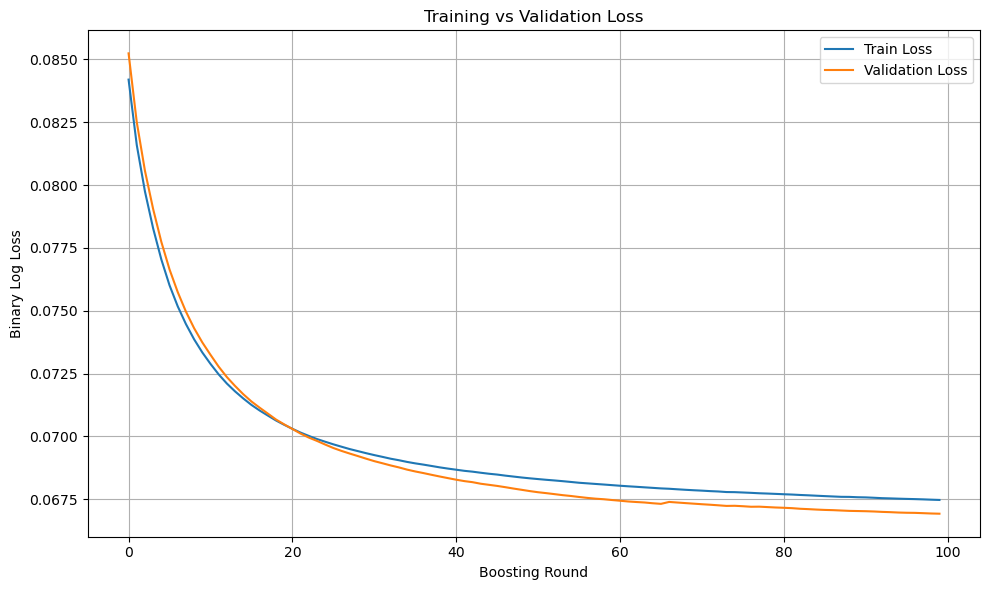

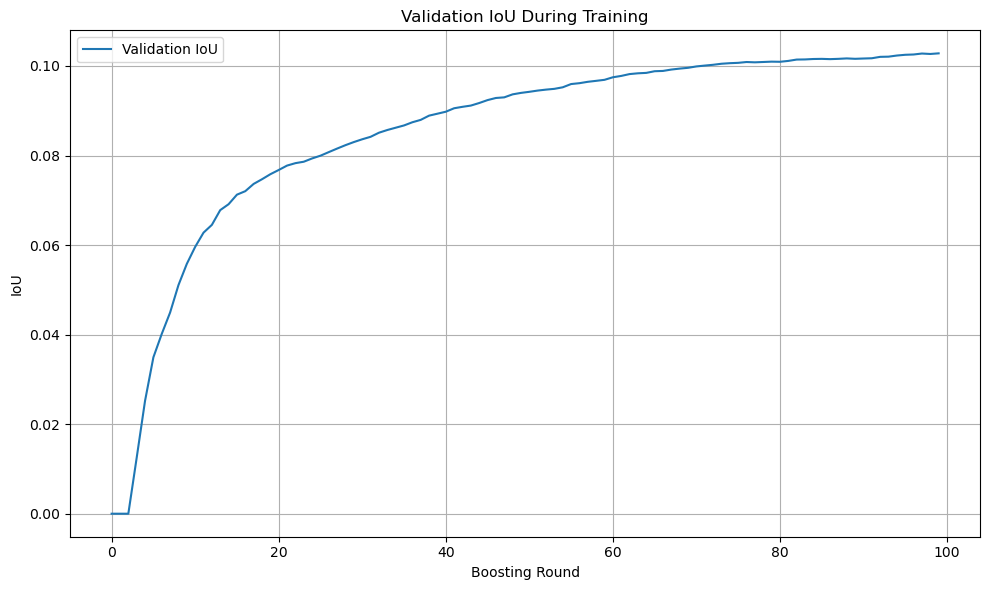

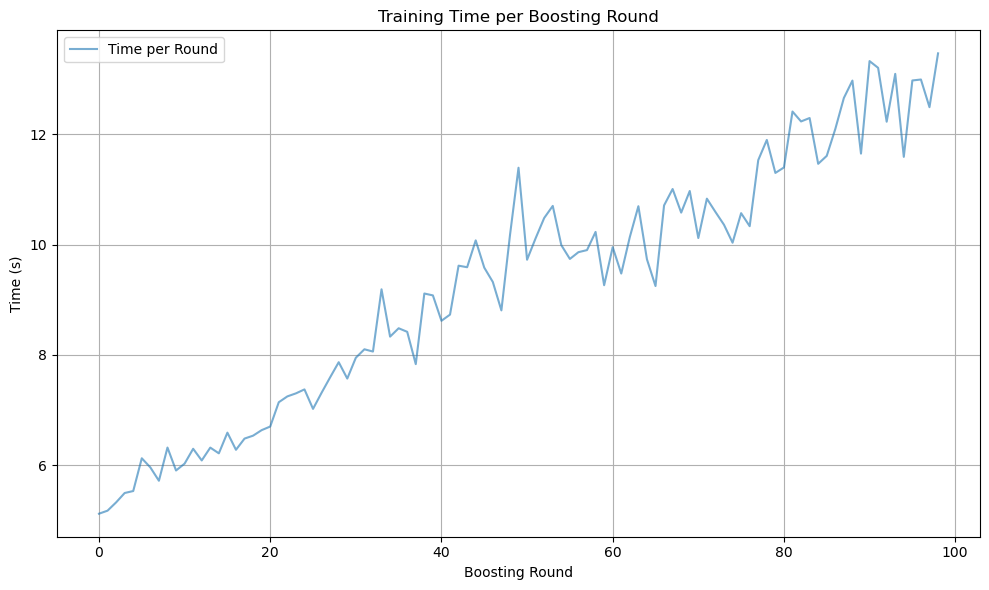

In [ ]:
import warnings
from rasterio.errors import NotGeoreferencedWarning
# Suppress irrelevant warnings
warnings.filterwarnings("ignore", category=NotGeoreferencedWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

os.makedirs(response_dir, exist_ok=True)

# # Reduced training subset for performance
# train_amount = 20
# train_df = train_df.head(train_amount).copy()
# val_df = val_df.head(int(train_amount / 7)).copy()

# Generate response tiles for training and validation
train_img_paths = [os.path.join(img_dir, f) for f in train_df['img_filename']]
val_img_paths = [os.path.join(img_dir, f) for f in val_df['img_filename']]

make_response_tiles(train_img_paths, train_df['label'], mask_dir, response_dir)
make_response_tiles(val_img_paths, val_df['label'], mask_dir, response_dir)

# Create input/response paths for training and validation
response_paths = [
    os.path.join(response_dir, f.replace(".png", ".tif")) for f in train_df['img_filename']
]
val_response_paths = [
    os.path.join(response_dir, f.replace(".png", ".tif")) for f in val_df['img_filename']
]

print("Input paths:", img_dir)
print("Response paths:", response_dir)
print(f"Training on {len(train_img_paths)} images")

clf, num_samples, _ = MyClassifierTrainer(
    force_col_wise=True
).train_classifier(
    img_filepaths=train_img_paths,
    response_img_filepaths=response_paths,
    val_img_filepaths=val_img_paths,
    val_response_img_filepaths=val_response_paths
)

# Save classifier (if enabled)
if save_model:
    joblib.dump(clf, "detectree_classifier.joblib")
    print("Classifier saved to detectree_classifier.joblib")


# Plot training and validation loss
train_runtime = training_times[-1] - training_times[0]
print(f"Total training runtime: {train_runtime:.2f} seconds")

num_rounds = len(training_times)
steps_per_second = num_rounds / train_runtime
print(f"Training steps/sec: {steps_per_second:.2f}")

train_loss = eval_results['training']['binary_logloss']
val_loss = eval_results['validation']['binary_logloss']

plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Boosting Round')
plt.ylabel('Binary Log Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot validation IoU during training
plt.figure(figsize=(10, 6))
plt.plot(val_iou_scores, label='Validation IoU')
plt.xlabel('Boosting Round')
plt.ylabel('IoU')
plt.title('Validation IoU During Training')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot training times
# Convert to time-per-round and cumulative time
round_durations = np.diff(training_times)

plt.figure(figsize=(10, 6))
plt.plot(round_durations, label='Time per Round', alpha=0.6)
plt.xlabel('Boosting Round')
plt.ylabel('Time (s)')
plt.title('Training Time per Boosting Round')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Predicting dead tree labels
With the trained classifier, healthy trees and standing dead trees can be predicted from any given tile.

In [ ]:
# For package modification
from detectree import Classifier, pixel_features
import maxflow as mf
MOORE_NEIGHBORHOOD_ARR = np.array([[0, 0, 0], [0, 0, 1], [1, 1, 1]])

class MyClassifier(Classifier):
    def _predict_img(self, img_filepath, clf, *, output_filepath=None):
        # ACHTUNG: Note that we do not use keyword-only arguments in this method because
        # `output_filepath` works as the only "optional" argument
        src = rio.open(img_filepath)
        img_shape = src.shape

        X = pixel_features.PixelFeaturesBuilder(
            **self.pixel_features_builder_kwargs
        ).build_features_from_filepath(img_filepath)

        if not self.refine:
            y_pred = clf.predict(X).reshape(img_shape)
        else:
            p_nontree, p_tree = np.hsplit(clf.predict_proba(X), 2)
            g = mf.Graph[int]()
            node_ids = g.add_grid_nodes(img_shape)
            P_nontree = p_nontree.reshape(img_shape)
            P_tree = p_tree.reshape(img_shape)
            P_nontree = np.clip(P_nontree, 1e-10, 1 - 1e-10)  # Clip probabilities to avoid 0 or 1
            P_tree = np.clip(P_tree, 1e-10, 1 - 1e-10)

            D_tree = (self.refine_int_rescale * np.log(P_nontree)).astype(int)
            D_nontree = (self.refine_int_rescale * np.log(P_tree)).astype(int)

            g.add_grid_edges(
                node_ids, self.refine_beta, structure=MOORE_NEIGHBORHOOD_ARR
            )
            g.add_grid_tedges(node_ids, D_tree, D_nontree)
            g.maxflow()

            y_pred = np.full(img_shape, self.nontree_val)
            y_pred[g.get_grid_segments(node_ids)] = self.tree_val

        if output_filepath is not None:
            with rio.open(
                output_filepath,
                "w",
                driver="GTiff",
                width=y_pred.shape[1],
                height=y_pred.shape[0],
                count=1,
                dtype=np.uint8,
                nodata=self.nontree_val,
                crs=src.crs,
                transform=src.transform,
            ) as dst:
                dst.write(y_pred.astype(np.uint8), 1)

        src.close()
        return y_pred

if not path.exists(pred_dir):
    os.mkdir(pred_dir)

c = MyClassifier(clf=clf)

# Modify DataFrame for detectree prediction
test_df['train'] = False
pred_tiles = c.predict_imgs(test_df, img_dir=test_img_dir, output_dir=pred_dir)

# Load and binarize GT and predicted masks
test_filepaths = [os.path.join(test_img_dir, f) for f in test_df['img_filename']]
mask_filepaths = [os.path.join(test_mask_dir, f) for f in test_df['label']]
pred_tiles = pred_tiles

def load_mask_tensor(filepath):
    # Binarize and preserve float
    img = Image.open(filepath).convert("L")
    tensor = TF.to_tensor(img)
    return (tensor > 0).float()

gt_masks = torch.stack([load_mask_tensor(p) for p in mask_filepaths])
pred_masks = torch.stack([load_mask_tensor(p) for p in pred_tiles])

# Calculate mean IoU from predictions
def compute_batch_iou(preds, targets, threshold=0, eps=1e-6):
    preds_bin = (preds > threshold).float()

    preds_bin = preds_bin.view(preds_bin.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds_bin * targets).sum(dim=1)
    union = (preds_bin + targets).sum(dim=1) - intersection

    iou = (intersection + eps) / (union + eps)
    return iou.mean().item(), iou.cpu().numpy()

mean_iou, image_ious = compute_batch_iou(pred_masks, gt_masks)
print(f"Mean IoU: {mean_iou:.4f}")

# Plot IoU per image
plt.figure(figsize=(12, 5))
plt.scatter(range(len(image_ious)), image_ious, label='IoU per image', color='#1f77b4', zorder=3)
plt.hlines(mean_iou, xmin=0, xmax=len(image_ious) - 1, color='red', linestyle='-', linewidth=2, label=f'Mean IoU = {mean_iou:.2f}')
for i, iou in enumerate(image_ious):
    plt.plot([i, i], [iou, mean_iou], linestyle='dotted', color='gray', zorder=2)

plt.title("IoU per Test Image")
plt.xlabel("Test Image Index")
plt.ylabel("IoU Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

def display_example_predictions(test_filepaths, gt_masks, pred_masks):
    # Example results
    for i in range(3):
        rgb_img = cv2.imread(test_filepaths[i])
        gt_mask = gt_masks[i]
        pred_mask = pred_masks[i]

        print(test_filepaths[i])

        # Manual IoU on example prediction
        intersection = np.logical_and(gt_mask == 1, pred_mask == 1).sum()
        union = np.logical_or(gt_mask == 1, pred_mask == 1).sum()
        iou = intersection / union
        print(f"Example IoU: {iou:.4f}")

        # Display
        fig, axs = plt.subplots(1, 3, figsize=(15, 5))

        axs[0].imshow(rgb_img)
        axs[0].set_title('RGB Image')
        axs[0].axis('off')

        axs[1].imshow(gt_mask.squeeze(), cmap='gray')
        axs[1].set_title('Ground Truth Mask')
        axs[1].axis('off')

        axs[2].imshow(pred_mask.squeeze(), cmap='gray')
        axs[2].set_title('Predicted Mask')
        axs[2].axis('off')

        plt.tight_layout()
        plt.show()


display_example_predictions(test_filepaths, gt_masks, pred_masks)

# Save predicted ndarrays as viewable images
pred_imgs_dir = 'training/viewable_preds'

def save_as_viewable(pred_paths, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    for pred_path in pred_paths:
        img = Image.open(pred_path)
        # Save to new location as viewable .png
        out_path = os.path.join(output_dir, f"{path.basename(pred_path)}.png")
        img.save(out_path)

# save_as_viewable(pred_tiles, pred_imgs_dir)

### Predicting with pre-trained model
Predictions can also be made with an existing pre-trained model as a .joblib file if it exists.<br>
Uncomment the code below and run to see results.

[########################################] | 100% Completed | 15.60 s
Mean IoU: 0.1250


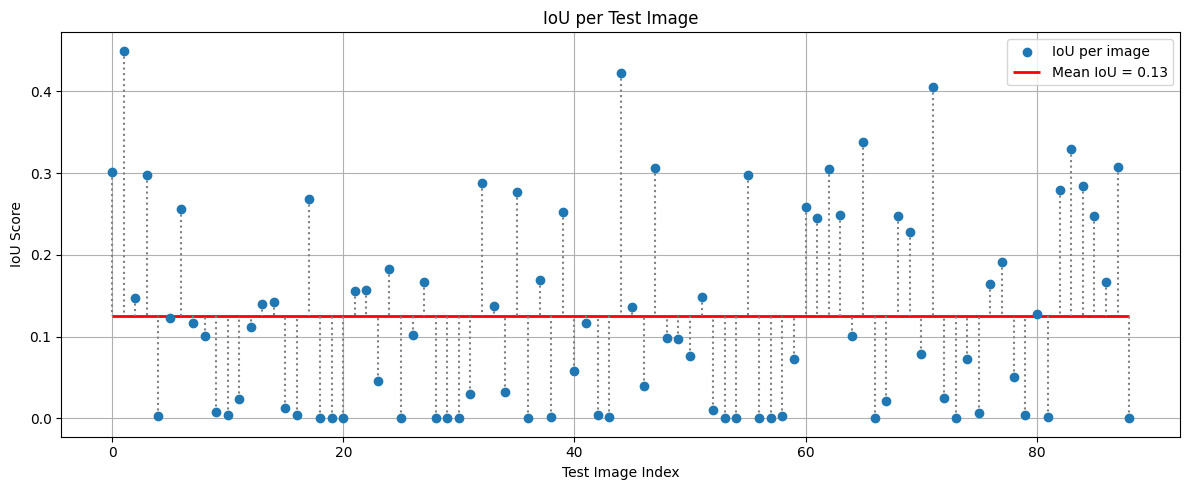

training/test_imgs/RGB_ar039_2019_n_07_11_0.png
Example IoU: 0.3009


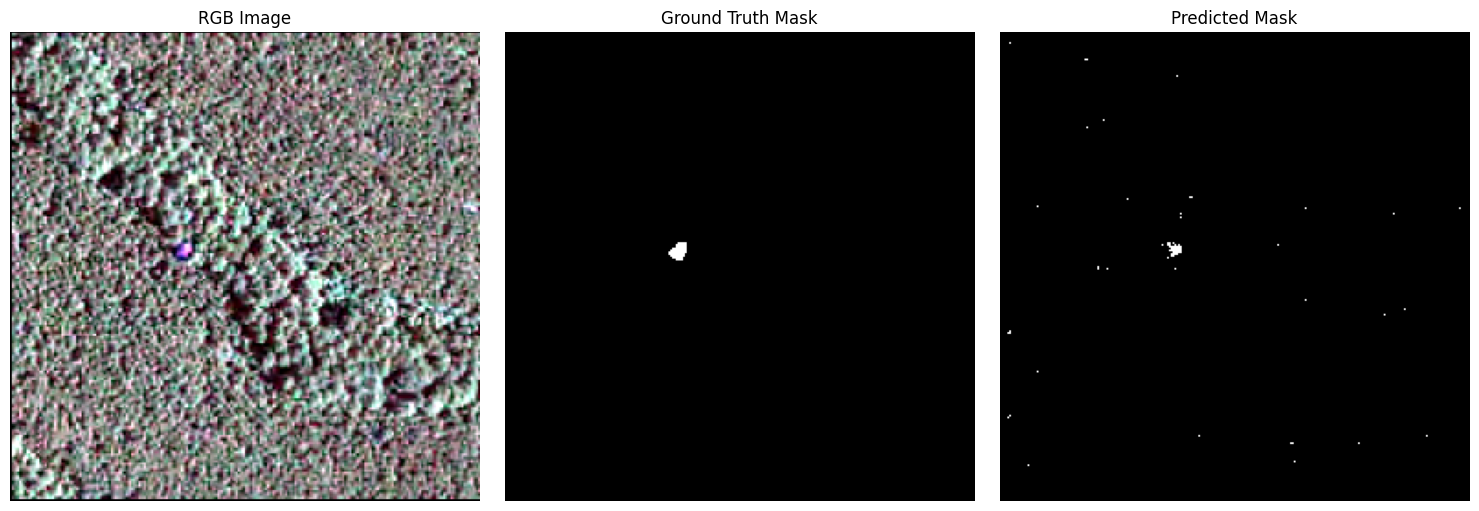

training/test_imgs/RGB_ar039_2019_n_08_14_0.png
Example IoU: 0.4497


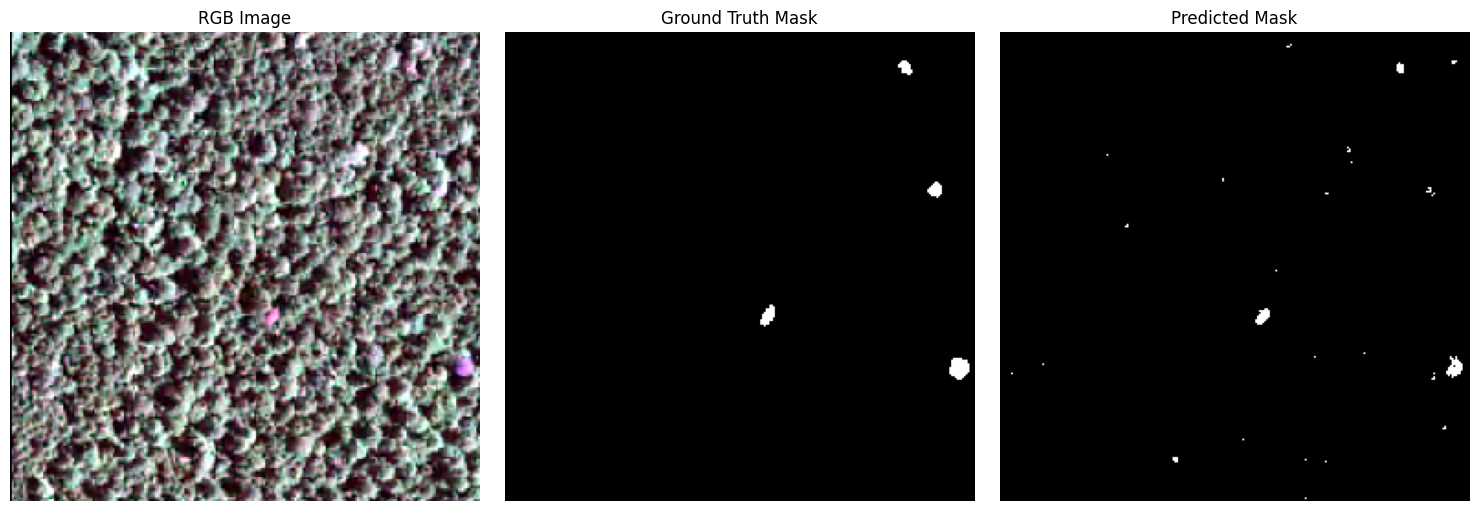

training/test_imgs/RGB_ar039_2019_n_10_07_0.png
Example IoU: 0.1477


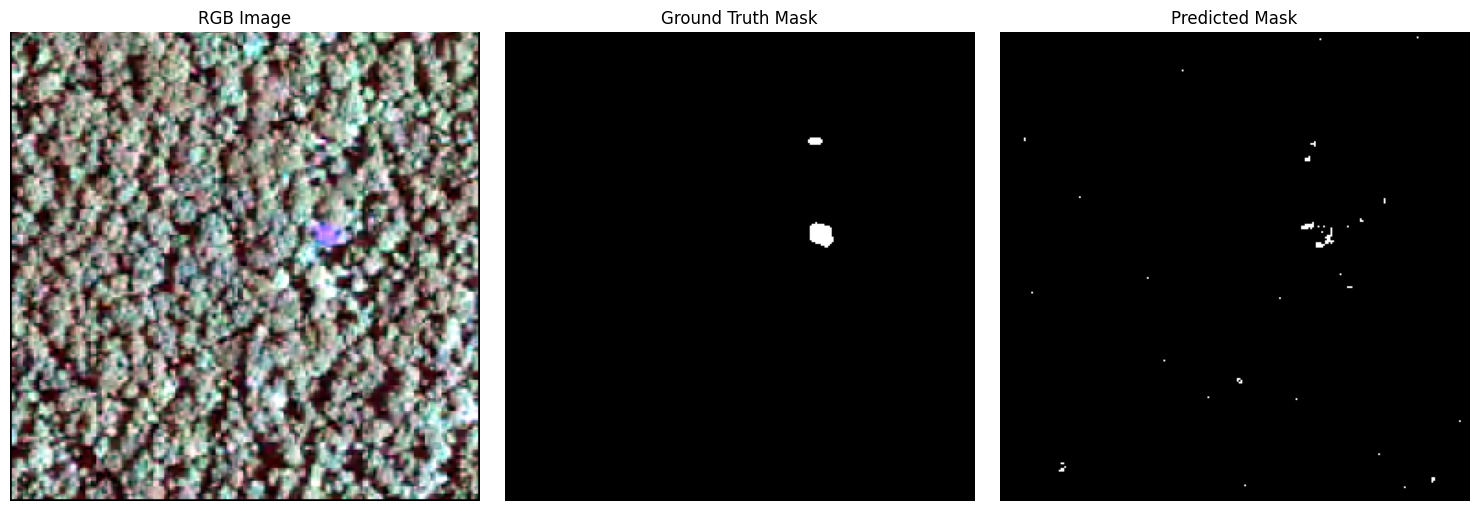

In [275]:
import detectree as dtr
import joblib

# Path to pre-trained model file
model_path = "detectree_classifier.joblib"

# Input image/mask directories
test_img_dir = "training/test_imgs"
test_mask_dir = "training/test_masks"
# Output predictions directory
pretrained_pred_dir = "training/pretrained_preds"
os.makedirs(pretrained_pred_dir, exist_ok=True)

c = dtr.Classifier()
c.clf = joblib.load(model_path)

# Create dataframe for prediction
image_files = sorted(os.listdir(test_img_dir))
mask_files = sorted(os.listdir(test_mask_dir))
df = pd.DataFrame({'img_filename': image_files, 'label': mask_files, 'train': False})

pred_tiles = c.predict_imgs(df, test_img_dir, pretrained_pred_dir)

# Load and binarize GT and predicted masks
test_filepaths = [os.path.join(test_img_dir, f) for f in df['img_filename']]
mask_filepaths = [os.path.join(test_mask_dir, f) for f in df['label']]

def load_mask_tensor(filepath):
    # Binarize and preserve float
    img = Image.open(filepath).convert("L")
    tensor = TF.to_tensor(img)
    return (tensor > 0).float()

gt_masks = torch.stack([load_mask_tensor(p) for p in mask_filepaths])
pred_masks = torch.stack([load_mask_tensor(p) for p in pred_tiles])

# Calculate mean IoU from predictions
def compute_batch_iou(preds, targets, threshold=0, eps=1e-6):
    preds_bin = (preds > threshold).float()

    preds_bin = preds_bin.view(preds_bin.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds_bin * targets).sum(dim=1)
    union = (preds_bin + targets).sum(dim=1) - intersection

    iou = (intersection + eps) / (union + eps)
    return iou.mean().item(), iou.cpu().numpy()

mean_iou, image_ious = compute_batch_iou(pred_masks, gt_masks)
print(f"Mean IoU: {mean_iou:.4f}")

# Plot IoU per image
plt.figure(figsize=(12, 5))
plt.scatter(range(len(image_ious)), image_ious, label='IoU per image', color='#1f77b4', zorder=3)
plt.hlines(mean_iou, xmin=0, xmax=len(image_ious) - 1, color='red', linestyle='-', linewidth=2, label=f'Mean IoU = {mean_iou:.2f}')
for i, iou in enumerate(image_ious):
    plt.plot([i, i], [iou, mean_iou], linestyle='dotted', color='gray', zorder=2)

plt.title("IoU per Test Image")
plt.xlabel("Test Image Index")
plt.ylabel("IoU Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

def display_example_predictions(test_filepaths, gt_masks, pred_masks):
    # Example results
    for i in range(3):
        rgb_img = cv2.imread(test_filepaths[i])
        gt_mask = gt_masks[i]
        pred_mask = pred_masks[i]

        print(test_filepaths[i])

        # Manual IoU on example prediction
        intersection = np.logical_and(gt_mask == 1, pred_mask == 1).sum()
        union = np.logical_or(gt_mask == 1, pred_mask == 1).sum()
        iou = intersection / union
        print(f"Example IoU: {iou:.4f}")

        # Display
        fig, axs = plt.subplots(1, 3, figsize=(15, 5))

        axs[0].imshow(rgb_img)
        axs[0].set_title('RGB Image')
        axs[0].axis('off')

        axs[1].imshow(gt_mask.squeeze(), cmap='gray')
        axs[1].set_title('Ground Truth Mask')
        axs[1].axis('off')

        axs[2].imshow(pred_mask.squeeze(), cmap='gray')
        axs[2].set_title('Predicted Mask')
        axs[2].axis('off')

        plt.tight_layout()
        plt.show()

display_example_predictions(test_filepaths, gt_masks, pred_masks)

### References
https://github.com/martibosch/detectree<br>
https://detectree.readthedocs.io/en/latest/<br>
https://github.com/martibosch/detectree-examples<br>
https://joss.theoj.org/papers/10.21105/joss.02172<br>
https://lightgbm.readthedocs.io/en/stable/